# Cloud-Cover Regressor - Balloon ML Payload (v2, regression variant)

Alternative to the 3-class cloud classifier. Instead of predicting clear / partial / overcast,
this model predicts the **cloud-cover fraction directly** as a continuous value in [0, 1]. It is
trained and evaluated on the same 95-Cloud-derived data, so the two can be compared head to head.

**Output:** `cloud_regressor.keras` (float). The classifier notebook is left untouched; this is a
parallel experiment you can keep or discard.

## 1. Approach

**Why regression.** The ground truth is a continuous cloud-pixel fraction (computed from the
segmentation masks by `build_cloud_classes.py` and stored in `manifest.csv`). The classifier threw
that number away by binning it into three classes, which created the partial-class boundary problem:
a patch at 48% and one at 52% cloud are nearly identical but get opposite labels. Predicting the
fraction directly removes the arbitrary bin boundaries entirely. The output is also more informative
(a percentage rather than a coarse bucket), and the telemetry shrinks to a single scalar.

**Method.** Same MobileNetV2 transfer-learning setup as the classifier (Edge TPU compatible
backbone, two-phase frozen-then-fine-tuned training, grayscale input replicated to 3 channels,
brightness/contrast augmentation for illumination robustness). Only the head and loss change: a
single sigmoid output (bounded to [0, 1]) trained with mean-squared error, reported as mean absolute
error (MAE) in cloud fraction.

**How we compare to the classifier.** At evaluation the predicted fraction is binned with the same
METAR thresholds (clear < 12.5%, partial 12.5-87.5%, overcast > 87.5%) into the three classes, so a
direct 3-class accuracy and confusion matrix can be placed next to the classifier's 0.805. The
regression also reports MAE, which the classifier cannot.

## 2. Dataset

Same source as the classifier: 95-Cloud (additional-to-38-Cloud), Landsat 8, originally per-pixel
cloud segmentation. Labels here are the continuous `cloud_fraction` column from
`cloud_classes/manifest.csv` (cloud-pixel fraction over the valid area of each patch), rather than
the binned class. Image preprocessing is identical: grayscale to match the HM01B0 camera, NIR
dropped, margin patches already filtered at generation time (min-valid 0.99).

## 3. Mission assumptions and limitations

These carry over unchanged from the classifier; the output format does not affect them.

**3.1 Viewing geometry.** Trained on satellite nadir view; the flight camera must look down.
Oblique mounting is out of distribution.

**3.2 Altitude and scale gap (dominant validation risk).** Landsat images from ~700 km at 30 m/px;
the balloon flies at ~30 km. Cloud scale and parallax differ, and this sim-to-real gap can only be
validated against real captured frames (the SD-card logging exists for this).

**3.3 Spectral channels (mono vs RGB).** Trained on grayscale to match the monochrome camera. RGB
would give a modest gain, mostly on bright-surface disambiguation; the decisive cue (NIR/SWIR) is on
no consumer camera. The bright-surface ambiguity (snow/ice/desert read as cloud) is intrinsic to
grayscale and limits accuracy on bright scenes.

**3.4 Illumination and time of day.** Landsat 8 is sun-synchronous (~10:30 local crossing): all
training imagery is daytime, mid-morning sun angles. Brightness/contrast augmentation here partially
mitigates this. Valid for daytime flight with reasonable sun elevation; dawn/dusk degrade, night is
moot for a visible camera.

**3.5 Surface domain.** Global Landsat scenes include snow, ice, and desert; the mission flies over
temperate Bavarian farmland in daylight, so those confusers are largely absent from the real flight
domain.

## 4. Setup

In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import csv
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print("TF", tf.__version__)
print(type(tf.keras.layers.Dense(1)).__module__)
gpus = tf.config.list_physical_devices("GPU")
print("GPUs:", gpus if gpus else "NONE (CPU - slower but works)")

DATA_DIR   = Path("cloud_classes")     # contains manifest.csv + class folders of PNGs
IMG_SIZE   = (224, 224)
BATCH      = 32
SEED       = 1337
EPOCHS_HEAD = 15
EPOCHS_FT   = 40
FINE_TUNE_AT = 80
MODEL_OUT  = "cloud_regressor.keras"
EDGES = [0.125, 0.875]                  # METAR thresholds for the binned comparison

I0000 00:00:1781010357.512416   60519 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781010357.740759   60519 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781010359.038038   60519 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TF 2.21.0
tf_keras.src.layers.core.dense
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 5. Load continuous labels from the manifest, split 80/20

In [2]:
recs = list(csv.DictReader(open(DATA_DIR / "manifest.csv")))
paths = [str(DATA_DIR / r["class"] / (r["patch"] + ".png")) for r in recs]
fracs = [float(r["cloud_fraction"]) for r in recs]
print("patches:", len(paths), "| fraction range: %.3f - %.3f" % (min(fracs), max(fracs)))

idx = np.arange(len(paths))
np.random.RandomState(SEED).shuffle(idx)
cut = int(0.8 * len(idx))
tr_i, va_i = idx[:cut], idx[cut:]
print("train:", len(tr_i), "val:", len(va_i))

patches: 13335 | fraction range: 0.000 - 1.000
train: 10668 val: 2667


## 6. Input pipeline (augment train only; label is the fraction)

In [3]:
AUTOTUNE = tf.data.AUTOTUNE

def load(path, frac):
    img = tf.io.decode_png(tf.io.read_file(path), channels=1)   # grayscale
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)                               # [0,255]
    return img, frac

def augment(x, y):
    x = tf.image.random_flip_left_right(x)
    x = tf.image.random_flip_up_down(x)
    x = tf.image.random_brightness(x, max_delta=25.0)
    x = tf.image.random_contrast(x, 0.85, 1.15)
    x = tf.clip_by_value(x, 0.0, 255.0)
    return x, y

def to_model(x, y):
    x = tf.image.grayscale_to_rgb(x)
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
    return x, y

def make_ds(indices, training):
    p = [paths[i] for i in indices]
    f = [fracs[i] for i in indices]
    ds = tf.data.Dataset.from_tensor_slices((p, f)).map(load, num_parallel_calls=AUTOTUNE).cache()
    if training:
        ds = ds.shuffle(2000).map(augment, num_parallel_calls=AUTOTUNE)
    ds = ds.map(to_model, num_parallel_calls=AUTOTUNE).batch(BATCH).prefetch(AUTOTUNE)
    return ds

train_ds = make_ds(tr_i, True)
val_ds   = make_ds(va_i, False)

I0000 00:00:1781010360.788554   60519 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4134 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


## 7. Sanity check: one batch with its fraction labels

batch: (32, 224, 224, 3) | label range: 0.00 - 1.00


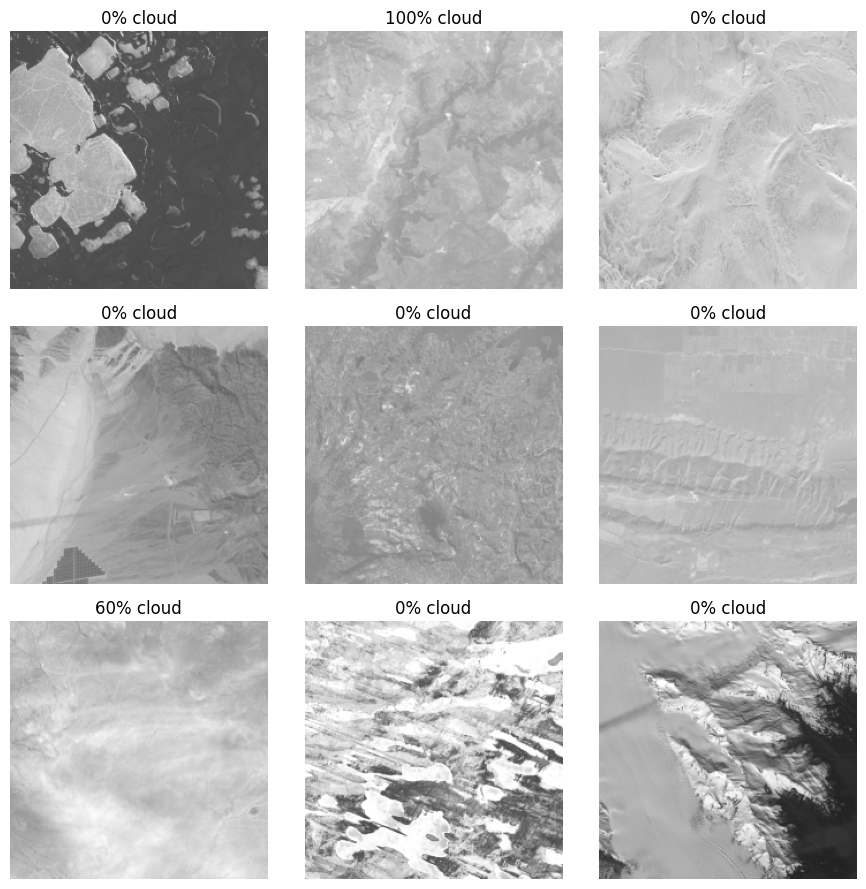

In [17]:
xb, fb = next(iter(train_ds))
print("batch:", xb.shape, "| label range: %.2f - %.2f" % (float(fb.numpy().min()), float(fb.numpy().max())))
plt.figure(figsize=(9, 9))
for i in range(min(9, xb.shape[0])):
    plt.subplot(3, 3, i + 1)
    plt.imshow((xb[i].numpy() + 1) / 2)
    plt.title("%.0f%% cloud" % (100 * float(fb[i]))); plt.axis("off")
plt.tight_layout(); plt.show()

## 8. Model and Phase 1 (frozen backbone + regression head)

In [5]:
base = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,), include_top=False, weights="imagenet")
base.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = base(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)    # cloud fraction in [0,1]
model = tf.keras.Model(inputs, outputs)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 mobilenetv2_1.00_224 (Func  (None, 7, 7, 1280)        2257984   
 tional)                                                         
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dropout (Dropout)           (None, 1280)              0         
                                                                 
 dense_1 (Dense)             (None, 1)                 1281      
                                                                 
Total params: 2259265 (8.62 MB)
Trainable params: 1281 (5.00 

In [6]:
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_HEAD)

Epoch 1/15


I0000 00:00:1781010364.283592   60629 cuda_dnn.cc:461] Loaded cuDNN version 92300


  2/334 [..............................] - ETA: 25s - loss: 0.2577 - mae: 0.4473  

I0000 00:00:1781010365.916082   60630 service.cc:153] XLA service 0x7fb0e486ab30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781010365.916100   60630 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.23.0)
I0000 00:00:1781010365.920051   60630 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1781010365.965085   60630 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


334/334 [==============================] - 21s 54ms/step - loss: 0.0904 - mae: 0.2153 - val_loss: 0.0654 - val_mae: 0.1751
Epoch 2/15
334/334 [==============================] - 17s 52ms/step - loss: 0.0686 - mae: 0.1768 - val_loss: 0.0590 - val_mae: 0.1622
Epoch 3/15
334/334 [==============================] - 18s 52ms/step - loss: 0.0630 - mae: 0.1675 - val_loss: 0.0547 - val_mae: 0.1580
Epoch 4/15
334/334 [==============================] - 18s 53ms/step - loss: 0.0598 - mae: 0.1625 - val_loss: 0.0551 - val_mae: 0.1582
Epoch 5/15
334/334 [==============================] - 17s 52ms/step - loss: 0.0583 - mae: 0.1595 - val_loss: 0.0520 - val_mae: 0.1503
Epoch 6/15
334/334 [==============================] - 16s 48ms/step - loss: 0.0572 - mae: 0.1574 - val_loss: 0.0522 - val_mae: 0.1489
Epoch 7/15
334/334 [==============================] - 16s 48ms/step - loss: 0.0566 - mae: 0.1548 - val_loss: 0.0509 - val_mae: 0.1452
Epoch 8/15
334/334 [==============================] - 16s 49ms/step - los

## 9. Phase 2 fine-tuning (unfreeze upper backbone, low LR)

In [7]:
base.trainable = True
for layer in base.layers[:FINE_TUNE_AT]:
    layer.trainable = False
for layer in base.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss="mse", metrics=["mae"])
early = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
history_ft = model.fit(train_ds, validation_data=val_ds,
                       epochs=EPOCHS_FT, callbacks=[early])

Epoch 1/40
334/334 [==============================] - 32s 76ms/step - loss: 0.0539 - mae: 0.1429 - val_loss: 0.0605 - val_mae: 0.1410
Epoch 2/40
334/334 [==============================] - 24s 70ms/step - loss: 0.0470 - mae: 0.1304 - val_loss: 0.0402 - val_mae: 0.1106
Epoch 3/40
334/334 [==============================] - 24s 71ms/step - loss: 0.0421 - mae: 0.1192 - val_loss: 0.0517 - val_mae: 0.1279
Epoch 4/40
334/334 [==============================] - 24s 71ms/step - loss: 0.0390 - mae: 0.1135 - val_loss: 0.0361 - val_mae: 0.1018
Epoch 5/40
334/334 [==============================] - 24s 71ms/step - loss: 0.0352 - mae: 0.1059 - val_loss: 0.0366 - val_mae: 0.1109
Epoch 6/40
334/334 [==============================] - 24s 71ms/step - loss: 0.0346 - mae: 0.1054 - val_loss: 0.0359 - val_mae: 0.1041
Epoch 7/40
334/334 [==============================] - 24s 71ms/step - loss: 0.0321 - mae: 0.0996 - val_loss: 0.0316 - val_mae: 0.0998
Epoch 8/40
334/334 [==============================] - 24s 70ms

## 10. Training curves (MAE)

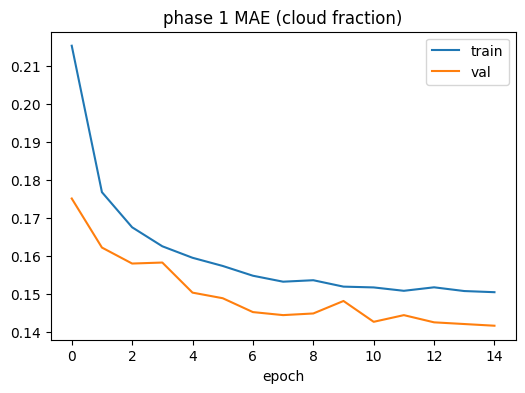

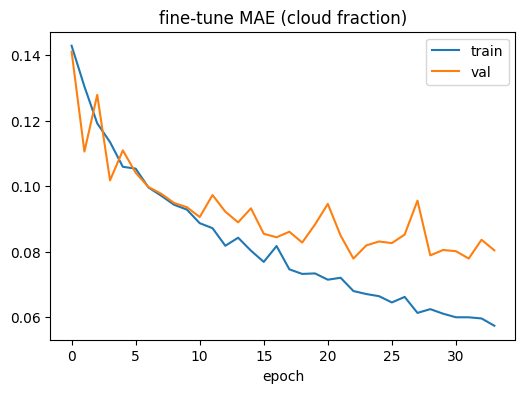

In [8]:
def plot_mae(h, title):
    plt.figure(figsize=(6,4))
    plt.plot(h["mae"], label="train"); plt.plot(h["val_mae"], label="val")
    plt.title(title + " MAE (cloud fraction)"); plt.xlabel("epoch"); plt.legend(); plt.show()
plot_mae(history.history, "phase 1")
plot_mae(history_ft.history, "fine-tune")

## 11. Save

In [9]:
model.save(MODEL_OUT)
print("saved", MODEL_OUT)

saved cloud_regressor.keras


## 12. Evaluation: MAE, scatter, and binned comparison to the classifier

The headline regression metric is MAE in cloud fraction. To compare against the classifier we bin
the predicted fraction with the METAR thresholds and compute 3-class accuracy on the same validation
patches. The scatter plot shows where the model is accurate and where error concentrates (expect the
mid-range to be hardest, the regression analogue of the partial class).

Validation MAE: 0.0789  (= 7.9 percentage points of cloud cover)


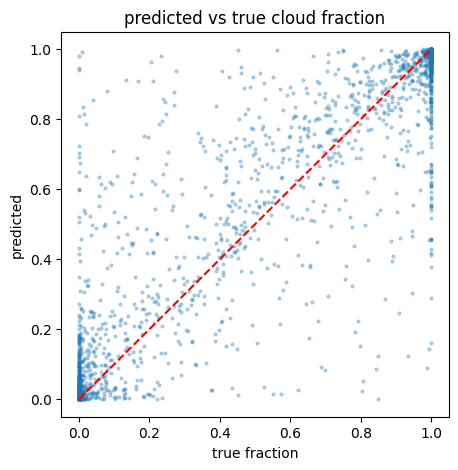


Binned 3-class accuracy: 0.851   (classifier was 0.805)
Confusion matrix, order: ['clear', 'overcast', 'partial']
[[953   5 147]
 [  2 836 122]
 [ 51  71 480]]
  clear     recall 0.862
  overcast  recall 0.871
  partial   recall 0.797

MAE by true class:
  clear     0.055 (5.5 pp)
  overcast  0.052 (5.2 pp)
  partial   0.167 (16.7 pp)


In [10]:
y_true_f, y_pred_f = [], []
for xb, fb in val_ds:
    pr = model.predict(xb, verbose=0).ravel()
    y_pred_f.extend(pr.tolist())
    y_true_f.extend(fb.numpy().tolist())
y_true_f = np.array(y_true_f); y_pred_f = np.array(y_pred_f)

mae = np.mean(np.abs(y_true_f - y_pred_f))
print("Validation MAE: %.4f  (= %.1f percentage points of cloud cover)" % (mae, 100*mae))

# scatter
plt.figure(figsize=(5,5))
plt.scatter(y_true_f, y_pred_f, s=4, alpha=0.3)
plt.plot([0,1],[0,1],"r--"); plt.xlabel("true fraction"); plt.ylabel("predicted")
plt.title("predicted vs true cloud fraction"); plt.show()

# binned 3-class comparison (clear=0, overcast=1, partial=2 to match classifier order)
def to_class(f):
    return 0 if f < EDGES[0] else (1 if f >= EDGES[1] else 2)
names = ["clear","overcast","partial"]
ct = np.array([to_class(f) for f in y_true_f])
cp = np.array([to_class(f) for f in y_pred_f])
cm = tf.math.confusion_matrix(ct, cp, num_classes=3).numpy()
acc = np.trace(cm)/cm.sum()
print("\nBinned 3-class accuracy: %.3f   (classifier was 0.805)" % acc)
print("Confusion matrix, order:", names); print(cm)
for i,c in enumerate(names):
    s = cm[i].sum(); print("  %-9s recall %.3f" % (c, cm[i,i]/s if s else 0))

# MAE by true bin (where does error concentrate?)
print("\nMAE by true class:")
for i,c in enumerate(names):
    m = ct==i
    if m.any(): print("  %-9s %.3f (%.1f pp)" % (c, np.mean(np.abs(y_true_f[m]-y_pred_f[m])), 100*np.mean(np.abs(y_true_f[m]-y_pred_f[m]))))

## 13. Int8 quantization (PTQ) and int8 evaluation

In [11]:
# representative set spanning the fraction range for good calibration
def representative_dataset():
    def b(f): return 0 if f < 0.125 else (1 if f >= 0.875 else 2)
    groups = {0: [], 1: [], 2: []}
    for k in range(len(tr_i)):
        groups[b(fracs[tr_i[k]])].append(tr_i[k])
    import random; rng = random.Random(0); pick = []
    for g in groups.values():
        rng.shuffle(g); pick += g[:150]
    for i in pick:
        img = tf.io.decode_png(tf.io.read_file(paths[i]), channels=1)
        img = tf.image.resize(img, IMG_SIZE); img = tf.cast(img, tf.float32)
        img = tf.image.grayscale_to_rgb(img)
        img = tf.keras.applications.mobilenet_v2.preprocess_input(img)
        yield [img[tf.newaxis, ...]]

conv = tf.lite.TFLiteConverter.from_keras_model(model)
conv.optimizations = [tf.lite.Optimize.DEFAULT]
conv.representative_dataset = representative_dataset
conv.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
conv.inference_input_type = tf.int8
conv.inference_output_type = tf.int8
tflite_model = conv.convert()
open("cloud_regressor_int8.tflite","wb").write(tflite_model)
print("wrote cloud_regressor_int8.tflite,", len(tflite_model), "bytes")

INFO:tensorflow:Assets written to: /tmp/tmpkoppa_2j/assets


INFO:tensorflow:Assets written to: /tmp/tmpkoppa_2j/assets
/home/khess/cubesat-ml/lib/python3.12/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1781011476.557996   60519 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1781011476.558059   60519 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1781011476.563386   60519 reader.cc:83] Reading SavedModel from: /tmp/tmpkoppa_2j
I0000 00:00:1781011476.594795   60519 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1781011476.594827   60519 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpkoppa_2j
I0000 00:00:1781011476.735680   60519 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1781011476.753471   60519 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1781011477.293691   6

wrote cloud_regressor_int8.tflite, 2711960 bytes


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
W0000 00:00:1781011532.387472   60519 flatbuffer_export.cc:3851] Skipping runtime version metadata in the model. This will be generated by the exporter.


In [12]:
interp = tf.lite.Interpreter(model_content=tflite_model)
interp.allocate_tensors()
ind, outd = interp.get_input_details()[0], interp.get_output_details()[0]
isc, izp = ind["quantization"]; osc, ozp = outd["quantization"]
print("input scale/zp:", isc, izp, "| output scale/zp:", osc, ozp)   # C++ needs these

yt, yp = [], []
for xb, fb in val_ds:
    for img, fr in zip(xb.numpy(), fb.numpy()):
        q = np.round(img/isc + izp).clip(-128,127).astype(np.int8)
        interp.set_tensor(ind["index"], q[np.newaxis,...]); interp.invoke()
        raw = interp.get_tensor(outd["index"])[0][0]
        yp.append((float(raw) - ozp) * osc)        # dequantize -> fraction
        yt.append(float(fr))
yt, yp = np.array(yt), np.array(yp)
print("\nINT8 MAE: %.4f (%.1f pp)" % (np.mean(np.abs(yt-yp)), 100*np.mean(np.abs(yt-yp))))
ct = np.array([to_class(f) for f in yt]); cp = np.array([to_class(f) for f in yp])
cm = tf.math.confusion_matrix(ct, cp, num_classes=3).numpy()
print("INT8 binned 3-class accuracy: %.3f   (classifier int8 was 0.805)" % (np.trace(cm)/cm.sum()))
print(cm)

/home/khess/cubesat-ml/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


input scale/zp: 0.007836860604584217 0 | output scale/zp: 0.00390625 -128

INT8 MAE: 0.1627 (16.3 pp)
INT8 binned 3-class accuracy: 0.720   (classifier int8 was 0.805)
[[585  91 429]
 [  0 859 101]
 [ 29  97 476]]


## 14. QAT

In [13]:
# Flatten + Transfer 
import tensorflow_model_optimization as tfmot
trained = tf.keras.models.load_model(MODEL_OUT)
trained_base = [l for l in trained.layers if isinstance(l, tf.keras.Model)][0]

base_new = tf.keras.applications.MobileNetV2(input_shape=IMG_SIZE+(3,), include_top=False, weights=None)
x = tf.keras.layers.GlobalAveragePooling2D()(base_new.output)
x = tf.keras.layers.Dropout(0.2)(x)
out = tf.keras.layers.Dense(1, activation="sigmoid")(x)
flat = tf.keras.Model(base_new.input, out)
base_new.set_weights(trained_base.get_weights())
flat.layers[-1].set_weights(trained.layers[-1].get_weights())
print("flat layers:", len(flat.layers))

flat layers: 157


In [14]:
# QAT wrap + fine-tune
q_aware = tfmot.quantization.keras.quantize_model(flat)
q_aware.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss="mse", metrics=["mae"])
early = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
q_aware.fit(train_ds, validation_data=val_ds, epochs=15, callbacks=[early])

Epoch 1/15
334/334 [==============================] - 154s 363ms/step - loss: 0.1127 - mae: 0.1940 - val_loss: 0.1816 - val_mae: 0.2718
Epoch 2/15
334/334 [==============================] - 111s 332ms/step - loss: 0.0784 - mae: 0.1507 - val_loss: 0.1229 - val_mae: 0.2050
Epoch 3/15
334/334 [==============================] - 112s 336ms/step - loss: 0.0676 - mae: 0.1388 - val_loss: 0.1027 - val_mae: 0.1798
Epoch 4/15
334/334 [==============================] - 112s 335ms/step - loss: 0.0585 - mae: 0.1279 - val_loss: 0.0614 - val_mae: 0.1275
Epoch 5/15
334/334 [==============================] - 120s 358ms/step - loss: 0.0560 - mae: 0.1257 - val_loss: 0.0546 - val_mae: 0.1199
Epoch 6/15
334/334 [==============================] - 115s 346ms/step - loss: 0.0520 - mae: 0.1212 - val_loss: 0.0546 - val_mae: 0.1200
Epoch 7/15
334/334 [==============================] - 116s 347ms/step - loss: 0.0491 - mae: 0.1196 - val_loss: 0.0472 - val_mae: 0.1111
Epoch 8/15
334/334 [============================

In [15]:
# Convert
conv = tf.lite.TFLiteConverter.from_keras_model(q_aware)
conv.optimizations = [tf.lite.Optimize.DEFAULT]
conv.representative_dataset = representative_dataset
conv.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
conv.inference_input_type = tf.int8
conv.inference_output_type = tf.int8
qat_tflite = conv.convert()
with open("cloud_regressor_qat_int8.tflite", "wb") as f:
    f.write(qat_tflite)
print("wrote cloud_regressor_qat_int8.tflite,", len(qat_tflite), "bytes")

INFO:tensorflow:Assets written to: /tmp/tmpt8yz4qpi/assets


INFO:tensorflow:Assets written to: /tmp/tmpt8yz4qpi/assets
/home/khess/cubesat-ml/lib/python3.12/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1781013391.420960   60519 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1781013391.421020   60519 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1781013391.421927   60519 reader.cc:83] Reading SavedModel from: /tmp/tmpt8yz4qpi
I0000 00:00:1781013391.464938   60519 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1781013391.465029   60519 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpt8yz4qpi
I0000 00:00:1781013391.691791   60519 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1781013392.618718   60519 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpt8yz4qpi
I0000 00:00:1781013392.

wrote cloud_regressor_qat_int8.tflite, 2710728 bytes


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
W0000 00:00:1781013405.412871   60519 flatbuffer_export.cc:3851] Skipping runtime version metadata in the model. This will be generated by the exporter.


In [16]:
# Evaluate
interp = tf.lite.Interpreter(model_content=qat_tflite)
interp.allocate_tensors()
ind, outd = interp.get_input_details()[0], interp.get_output_details()[0]
isc, izp = ind["quantization"]; osc, ozp = outd["quantization"]

yt, yp = [], []
for xb, fb in val_ds:
    for img, fr in zip(xb.numpy(), fb.numpy()):
        q = np.round(img/isc + izp).clip(-128, 127).astype(np.int8)
        interp.set_tensor(ind["index"], q[np.newaxis, ...]); interp.invoke()
        raw = interp.get_tensor(outd["index"])[0][0]
        yp.append((float(raw) - ozp) * osc); yt.append(float(fr))
yt, yp = np.array(yt), np.array(yp)
print("QAT int8 MAE: %.1f pp   (PTQ int8 was 12.4 pp, float ~8.6 pp)" % (100*np.mean(np.abs(yt-yp))))
ct = np.array([to_class(f) for f in yt]); cp = np.array([to_class(f) for f in yp])
cm = tf.math.confusion_matrix(ct, cp, num_classes=3).numpy()
print("QAT int8 binned 3-class accuracy: %.3f   (PTQ was 0.757)" % (np.trace(cm)/cm.sum()))
print(cm)
for i, c in enumerate(["clear","overcast","partial"]):
    m = ct == i
    if m.any(): print("  %-9s MAE %.1f pp" % (c, 100*np.mean(np.abs(yt[m]-yp[m]))))

/home/khess/cubesat-ml/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


QAT int8 MAE: 10.2 pp   (PTQ int8 was 12.4 pp, float ~8.6 pp)
QAT int8 binned 3-class accuracy: 0.800   (PTQ was 0.757)
[[995   2 108]
 [ 25 745 190]
 [105 104 393]]
  clear     MAE 3.7 pp
  overcast  MAE 11.2 pp
  partial   MAE 20.6 pp


## 14. Comparison summary

Fill in after running, to decide classifier vs regressor:

| model            | int8 binned 3-class acc | int8 MAE (pp) | partial/mid handling |
|------------------|-------------------------|---------------|----------------------|
| classifier (v1)  | 0.807                   | n/a           | partial recall 0.60  |
| regressor (v2)   | 0.800                   | 10.2          | partial MAE ~20 pp   |

If the regressor's binned accuracy matches or beats 0.805 **and** its MAE is low, it is the better
model: same or better classification, plus a continuous output and no bin-boundary fragility. If
binned accuracy is clearly worse, keep the classifier. The MAE-by-class numbers from Section 12 show
whether the mid-range (the old partial problem) is handled more gracefully as regression error than
as a collapsed class.

QAT regressor selected as the deployment model — continuous cloud-fraction output at ~10 pp int8 MAE, binned accuracy on par with the classifier, plus the richer output. (QAT numbers vary ~0.80–0.81 / ~9.6–10.2 pp across runs.) 